# pre3에서는?

## 먼저 해찬님과 같이 더블체크 (일반 8개 그래프) (완료)

1. 총 발송 수

2. 총 열람 수

3. 총 완료 수

4. 전체 완료율 (%)

5. 총 오퍼 연계 매출 (다중 오퍼 = 멀티 있는 것으로 추가 수정)

6. 발송 1건당 평균 매출

7. 오퍼 1건당 평균 매출

8. 오퍼별 ARPU (다중 오퍼 = 멀티 있는 것으로 추가 수정)



## 다음은 퍼널2 (우연적 전환)에 맞춘 8개 그래프 (진행중)

# 일반 8개 그래프 그리기

In [44]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 스타벅스 공식 컬러 팔레트 정의

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [84]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")
trans = pd.read_csv("../../Data/transactions_260325.csv")

In [47]:
print(merge_df.info())

display(merge_df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,0.0,NaN
1,0009655768c64bdeb2e877511632db8f,received,576,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,0,1,1.0,NaN
2,0009655768c64bdeb2e877511632db8f,received,336,3f207df678b143eea3cee63160fa8bed,NaN,NaN,15,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,0,1,1.0,NaN
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
4,0009655768c64bdeb2e877511632db8f,received,168,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,8,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,0,1,1.0,NaN


## Viewed 기록 중복 확인 코드

In [48]:
viewed_df = merge_df[merge_df['event'] == 'viewed']
viewed_df.head(2)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
5,0009655768c64bdeb2e877511632db8f,viewed,192,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,9,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,1,0,1.0,NaN


사람, 오퍼 아이디, 시간 모두 보기

In [49]:
view_counts = viewed_df.groupby(['person', 'offer_label','time']).size().reset_index(name='count')
view_counts

,person,offer_label,time,count
0,0009655768c64bdeb2e877511632db8f,bogo_4,456,1
1,0009655768c64bdeb2e877511632db8f,discount_3,540,1
2,0009655768c64bdeb2e877511632db8f,informational_1,372,1
3,0009655768c64bdeb2e877511632db8f,informational_2,192,1
4,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,1
...,...,...,...,...
57720,ffff82501cea40309d5fdd7edcca4a07,discount_1,174,1
57721,ffff82501cea40309d5fdd7edcca4a07,discount_3,6,1
57722,ffff82501cea40309d5fdd7edcca4a07,discount_4,354,1
57723,ffff82501cea40309d5fdd7edcca4a07,discount_4,414,1


중복 나오지 않음

In [50]:
multiple_views = view_counts[view_counts['count'] > 1]

if len(multiple_views) > 0:
    print(f"중복 {len(multiple_views)}건")
    display(multiple_views.sort_values(by='count', ascending=False).head(10))
else:
    print("오퍼를 딱 한 번씩만 열람")

오퍼를 딱 한 번씩만 열람


In [51]:
duplicated_views = viewed_df[viewed_df.duplicated(subset=['person', 'offer_label'], keep=False)]

duplicated_views_sorted = duplicated_views.sort_values(by=['person', 'offer_label', 'time'])
display(duplicated_views_sorted[['person', 'offer_label', 'time', 'event']].head(10))

,person,offer_label,time,event
21,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,viewed
23,00116118485d4dfda04fdbaba9a87b5c,bogo_4,630,viewed
94,003d66b6608740288d6cc97a6903f4f0,discount_3,300,viewed
97,003d66b6608740288d6cc97a6903f4f0,discount_3,420,viewed
158,004c5799adbf42868b9cff0396190900,bogo_4,408,viewed
161,004c5799adbf42868b9cff0396190900,bogo_4,516,viewed
164,004c5799adbf42868b9cff0396190900,discount_3,174,viewed
168,004c5799adbf42868b9cff0396190900,discount_3,648,viewed
185,005500a7188546ff8a767329a2f7c76a,bogo_1,60,viewed
187,005500a7188546ff8a767329a2f7c76a,bogo_1,186,viewed


사람 & offer label로만 봤을 때 중복되는 데이터 보기 -> time은 다른 것을 볼 수 있음

**시간이 다르기 때문에 중복이 아니라고 판단**

## 1. 총 발송 수 

오퍼 수신 이벤트만 골라서

총 몇 건의 오퍼가 뿌려졌는지 계산

오퍼를 받은 사람 수도 세보자

In [52]:
# 오퍼 수신 이벤트 (informational 제외)
received_df = merge_df[merge_df['event']=='received']

target_info = ['informational_1', 'informational_2']
received_df = received_df[~received_df['offer_label'].isin(target_info)]

# 총 몇 건의 오퍼
total_received_count = len(received_df)

# 오퍼를 받은 총 고객 수
unique_receivers = received_df['person'].nunique()

print(f"스타벅스가 뿌린 총 오퍼 건수: {total_received_count:,} 건")
print(f"오퍼를 받은 총 고객 수: {unique_receivers:,} 명")

스타벅스가 뿌린 총 오퍼 건수: 61,042 건
오퍼를 받은 총 고객 수: 16,928 명


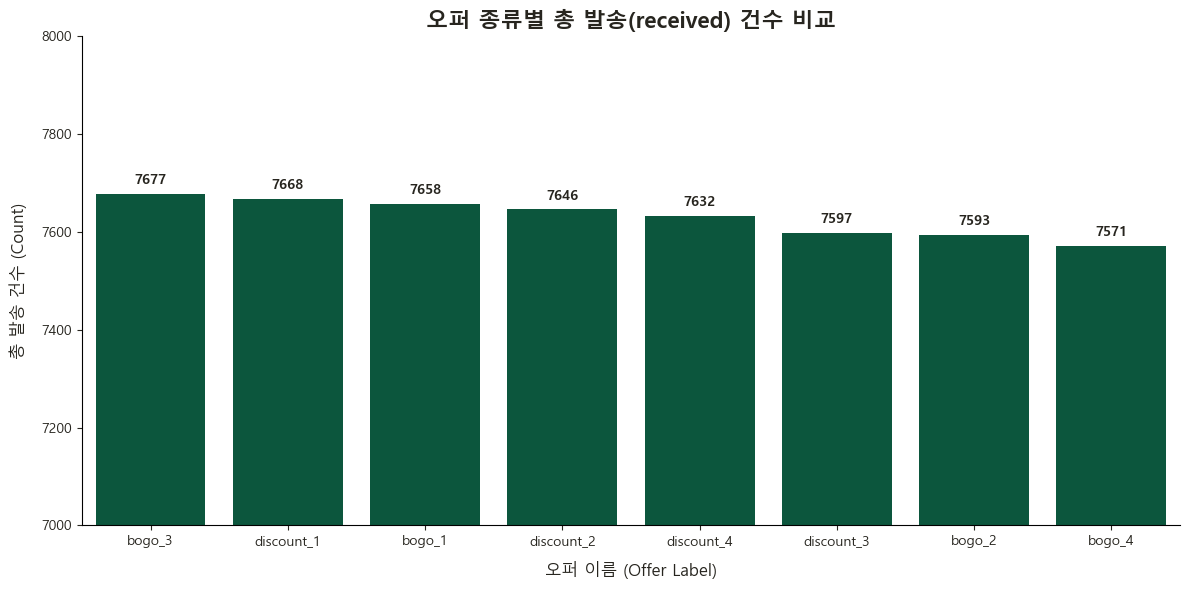

In [53]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=received_df, 
    x='offer_label', 
    order=received_df['offer_label'].value_counts().index
)
# y축 조절
plt.ylim(7000, 8000)

plt.title('오퍼 종류별 총 발송(received) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 발송 건수 (Count)', fontsize=12, labelpad=10)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. 총 열람 수 

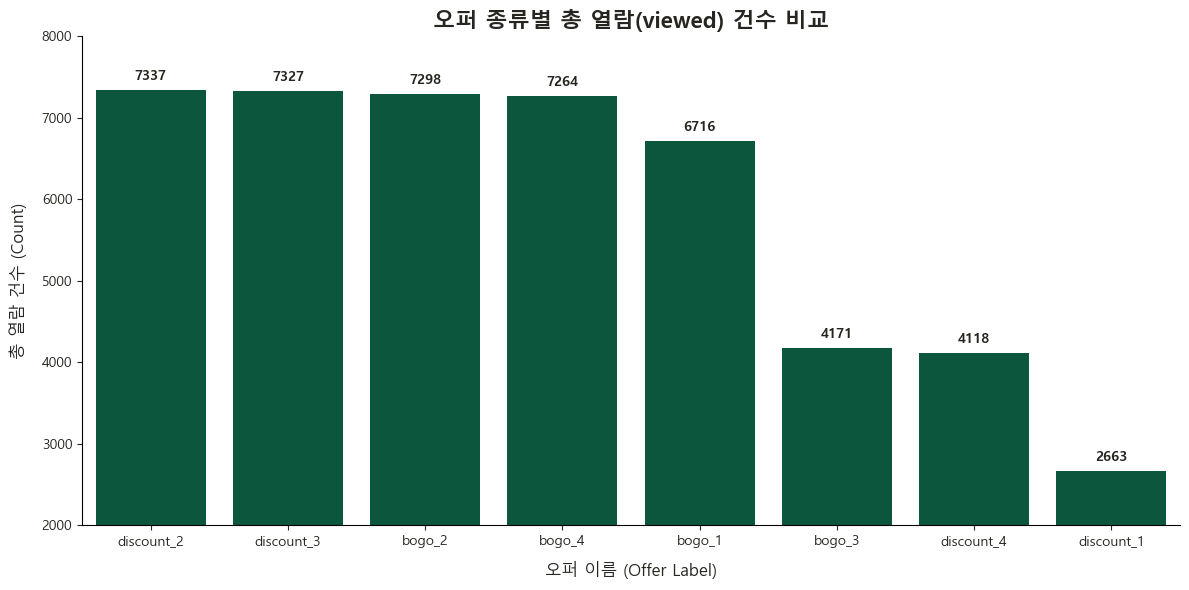

In [54]:
viewed_df = merge_df[merge_df['event'] == 'viewed']

target_info = ['informational_1', 'informational_2']
viewed_df = viewed_df[~viewed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=viewed_df, 
    x='offer_label', 
    order=viewed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 8000)

plt.title('오퍼 종류별 총 열람(viewed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 열람 건수 (Count)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 3. 총 완료 수

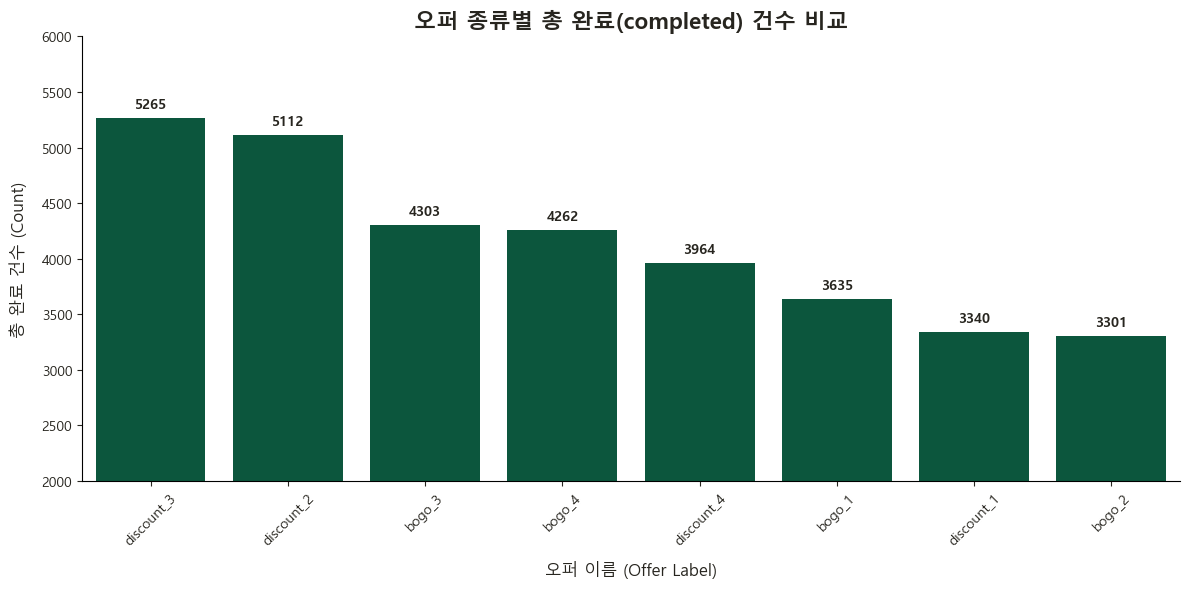

In [55]:
completed_df = merge_df[merge_df['event'] == 'completed']

target_info = ['informational_1', 'informational_2']
completed_df = completed_df[~completed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=completed_df, 
    x='offer_label', 
    order=completed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 6000)

plt.title('오퍼 종류별 총 완료(completed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 완료 건수 (Count)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. 전체 완료율(%)



발송과 완료의 비율 비교

완료율(%) = (완료 수 / 발송 수) * 100

In [56]:
import pandas as pd

# 1. 오퍼별로 발송(received) 건수
received_counts = received_df.groupby('offer_label').size().reset_index(name='received_count')

# 2. 오퍼별로 완료(completed) 건수
completed_counts = completed_df.groupby('offer_label').size().reset_index(name='completed_count')

# 3. 두 데이터를 'offer_label'을 기준으로 하나로 합침
funnel_df = pd.merge(received_counts, completed_counts, on='offer_label', how='left')

# 4. 완료율(%) = (완료 수 / 발송 수) * 100
funnel_df['completion_rate(%)'] = (funnel_df['completed_count'] / funnel_df['received_count']) * 100

funnel_df = funnel_df.sort_values(by='completion_rate(%)', ascending=False).reset_index(drop=True)


display(funnel_df.style.format({
    'received_count': '{:,} 건', 
    'completed_count': '{:,} 건',
    'completion_rate(%)': '{:.2f} %'
}))

,offer_label,received_count,completed_count,completion_rate(%)
0,discount_3,"7,597 건","5,265 건",69.30 %
1,discount_2,"7,646 건","5,112 건",66.86 %
2,bogo_4,"7,571 건","4,262 건",56.29 %
3,bogo_3,"7,677 건","4,303 건",56.05 %
4,discount_4,"7,632 건","3,964 건",51.94 %
5,bogo_1,"7,658 건","3,635 건",47.47 %
6,discount_1,"7,668 건","3,340 건",43.56 %
7,bogo_2,"7,593 건","3,301 건",43.47 %


In [57]:
print(received_counts.head(2))
print(completed_counts.head(2))

  offer_label  received_count
0      bogo_1            7658
1      bogo_2            7593
  offer_label  completed_count
0      bogo_1             3635
1      bogo_2             3301


#### 전체 완료율 그래프

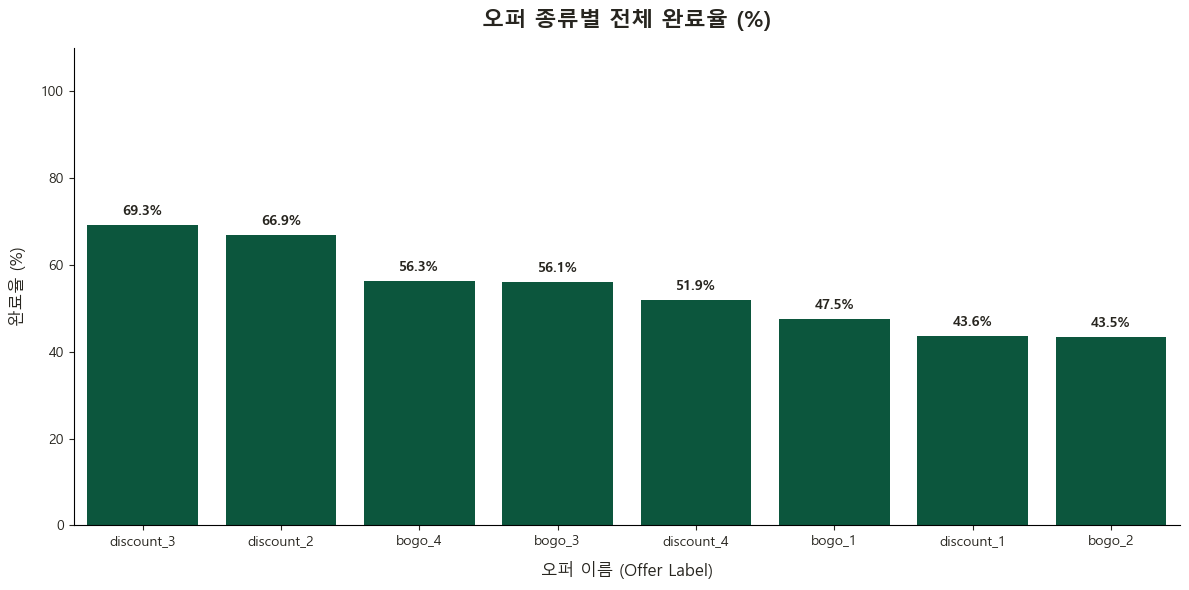

In [58]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=funnel_df, 
    x='offer_label', 
    y='completion_rate(%)'
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 110)

plt.title('오퍼 종류별 전체 완료율 (%)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 5. 총 오퍼 연계 매출 ($)

left join이후 쿠폰을 쓰고 결제한 경우에는 offer_label이 붙는다.

일반 결제는 offer_label이 nan

In [59]:
print(completed_df.head())

                              person      event  time  \
0   0009655768c64bdeb2e877511632db8f  completed   576   
7   0009655768c64bdeb2e877511632db8f  completed   414   
10  0009655768c64bdeb2e877511632db8f  completed   528   
29  0011e0d4e6b944f998e987f904e8c1e5  completed   576   
32  0011e0d4e6b944f998e987f904e8c1e5  completed   252   

                            offer_id  amount  bonus_reward  time_days gender  \
0   2906b810c7d4411798c6938adc9daaa5     NaN           2.0         25      M   
7   f19421c1d4aa40978ebb69ca19b0e20d     NaN           5.0         18      M   
10  fafdcd668e3743c1bb461111dcafc2a4     NaN           2.0         23      M   
29  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN           5.0         25      O   
32  2298d6c36e964ae4a3e7e9706d1fb8c2     NaN           3.0         11      O   

     age                       customer_id became_member_on   income  \
0   33.0  0009655768c64bdeb2e877511632db8f       2017-04-21  72000.0   
7   33.0  0009655768c64bdeb2e877

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 결제 데이터 준비
transactions_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]
completed_df = merge_df[merge_df['event']=='completed'][['person','time','offer_label']]
# 2. left join
sales_df = pd.merge(transactions_df, completed_df[['person', 'time', 'offer_label']], on=['person', 'time'], how='left')
# 3. 카테고리 분류기 (일반 결제 / discount / bogo)
def get_payment_category(label):
    if pd.isna(label): 
        return '일반 결제'
    elif 'discount' in str(label).lower(): 
        return 'discount'
    elif 'bogo' in str(label).lower(): 
        return 'bogo'
    else:
        return '기타'

# category 컬럼
sales_df['category'] = sales_df['offer_label'].apply(get_payment_category)

# 4. 카테고리별로 매출액(amount) 총합
revenue_summary = sales_df.groupby('category')['amount'].sum().reset_index()

# 5. 순서
order_list = ['일반 결제', 'discount', 'bogo']
revenue_summary['category'] = pd.Categorical(revenue_summary['category'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('category')


In [61]:
sales_df.head()

,person,time,amount,offer_label,category
0,0009655768c64bdeb2e877511632db8f,228,22.16,NaN,일반 결제
1,0009655768c64bdeb2e877511632db8f,414,8.57,bogo_4,bogo
2,0009655768c64bdeb2e877511632db8f,528,14.11,discount_3,discount
3,0009655768c64bdeb2e877511632db8f,552,13.56,NaN,일반 결제
4,0009655768c64bdeb2e877511632db8f,576,10.27,discount_4,discount


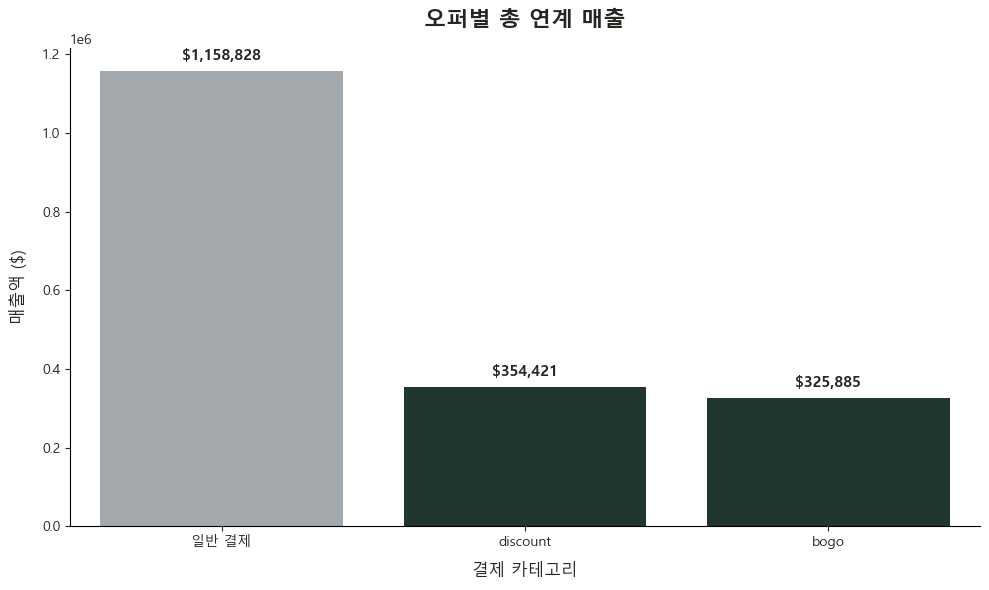

In [62]:
plt.figure(figsize=(10, 6))

color_palette = [SB_GREY, SB_DEEP_GREEN, SB_DEEP_GREEN]

ax = sns.barplot(
    data=revenue_summary, 
    x='category', 
    y='amount', 
    palette=color_palette
)

for container in ax.containers:
    labels = [f'${int(val):,}'  for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.title('오퍼별 총 연계 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('매출액 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# 비상 : 오퍼별 총 연계 매출 수정

In [95]:
trans[trans['txn_offer_type']=='multi'].shape

(1390, 19)

In [98]:
revenue_summary = trans.groupby('txn_offer_type')['amount'].sum().reset_index()

# 출력용 이름
type_mapping = {
    'normal': '일반 결제',
    'discount': 'discount',
    'bogo': 'bogo',
    'multi': '다중 결제'
}
revenue_summary['category'] = revenue_summary['txn_offer_type'].map(type_mapping)

# 3. 순서 정렬
order_list = ['일반 결제', 'discount', 'bogo', '다중 결제']
revenue_summary['category'] = pd.Categorical(revenue_summary['category'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('category')

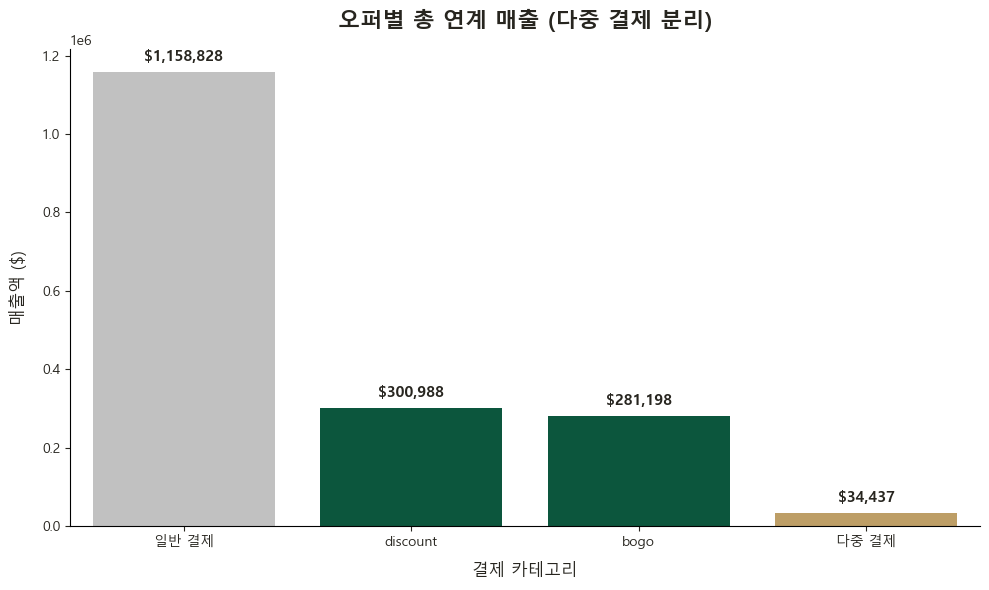

,category,amount
3,일반 결제,"$1,158,828.29"
1,discount,"$300,988.08"
0,bogo,"$281,198.52"
2,다중 결제,"$34,437.08"


In [99]:
plt.figure(figsize=(10, 6))

color_palette = [SB_GREY, SB_GREEN, SB_GREEN, SB_GOLD]

ax = sns.barplot(
    data=revenue_summary, 
    x='category', 
    y='amount', 
    palette=color_palette
)

# 숫자 표시
for container in ax.containers:
    labels = [f'${int(val):,}' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.title('오퍼별 총 연계 매출 (다중 결제 분리)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('매출액 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# 데이터프레임 출력 확인
display(revenue_summary[['category', 'amount']].style.format({'amount': '${:,.2f}'}))

## 6. 발송 1건당 평균 매출

1건당 평균 매출 = 총매출액 / 총 발송 건수

In [63]:
# 1. 오퍼별로 총 발송 건수
sent_counts = received_df.groupby('offer_label').size().reset_index(name='sent_count')

# 2. 오퍼별 총 매출액 구하기
offer_revenue = sales_df.dropna(subset=['offer_label'])
revenue_per_offer = offer_revenue.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')

# 3. 데이터 합치기 (발송 건수 옆에 총매출액 붙이기)
roi_df = pd.merge(sent_counts, revenue_per_offer, on='offer_label', how='left')

# 빈칸은 0으로
roi_df['total_revenue'] = roi_df['total_revenue'].fillna(0)

# 4. 1건당 평균 매출 = 총매출액 / 총 발송 건수
roi_df['revenue_per_send($)'] = roi_df['total_revenue'] / roi_df['sent_count']

# 순서
roi_df = roi_df.sort_values(by='revenue_per_send($)', ascending=False).reset_index(drop=True)

오퍼별로 총 발송 건수

In [64]:
sent_counts

,offer_label,sent_count
0,bogo_1,7658
1,bogo_2,7593
2,bogo_3,7677
3,bogo_4,7571
4,discount_1,7668
5,discount_2,7646
6,discount_3,7597
7,discount_4,7632


오퍼별 총 매출

In [65]:
revenue_per_offer

,offer_label,total_revenue
0,bogo_1,87109.94
1,bogo_2,78562.14
2,bogo_3,77066.31
3,bogo_4,83146.93
4,discount_1,85985.53
5,discount_2,89848.17
6,discount_3,96900.08
7,discount_4,81687.95


1건당 평균 매출

In [66]:
roi_df

,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,7597,96900.08,12.755045
1,discount_2,7646,89848.17,11.751003
2,bogo_1,7658,87109.94,11.375025
3,discount_1,7668,85985.53,11.213554
4,bogo_4,7571,83146.93,10.982292
5,discount_4,7632,81687.95,10.703348
6,bogo_2,7593,78562.14,10.346653
7,bogo_3,7677,77066.31,10.038597


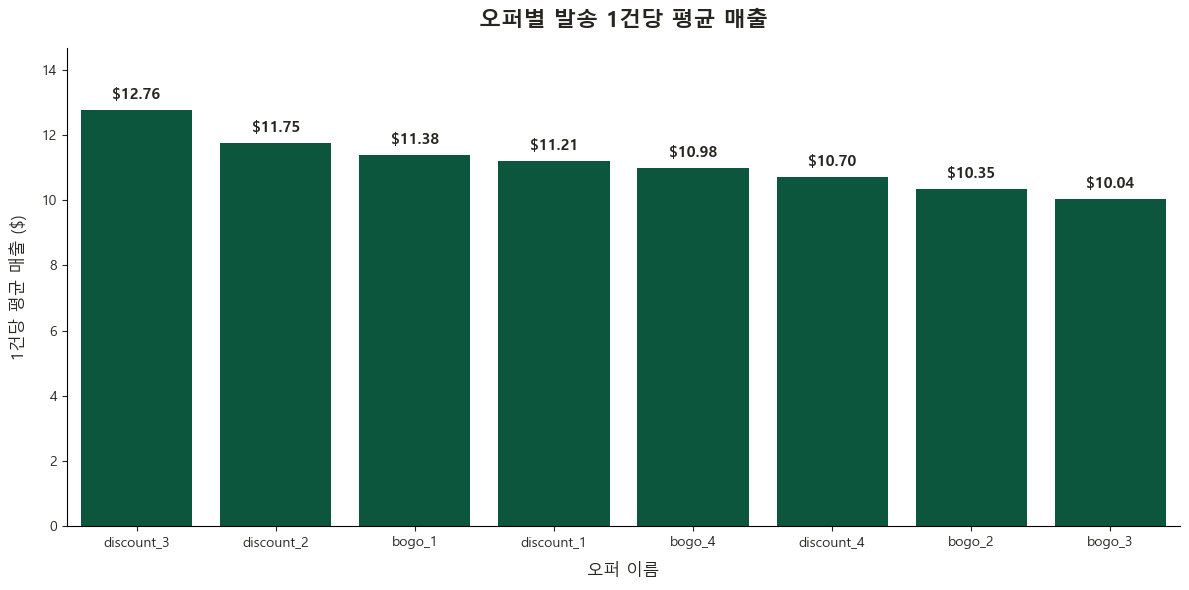


[오퍼별 효율성 상세 데이터]


,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,"7,597 건","$96,900.08",$12.76
1,discount_2,"7,646 건","$89,848.17",$11.75
2,bogo_1,"7,658 건","$87,109.94",$11.38
3,discount_1,"7,668 건","$85,985.53",$11.21
4,bogo_4,"7,571 건","$83,146.93",$10.98
5,discount_4,"7,632 건","$81,687.95",$10.70
6,bogo_2,"7,593 건","$78,562.14",$10.35
7,bogo_3,"7,677 건","$77,066.31",$10.04


In [67]:

plt.figure(figsize=(12, 6))

SB_GREEN = '#006241'

ax = sns.barplot(
    data=roi_df, 
    x='offer_label', 
    y='revenue_per_send($)', 
    color=SB_GREEN 
)

labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.ylim(0, roi_df['revenue_per_send($)'].max() * 1.15)
plt.title('오퍼별 발송 1건당 평균 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름', fontsize=12, labelpad=10)
plt.ylabel('1건당 평균 매출 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

print("\n[오퍼별 효율성 상세 데이터]")
display(roi_df.style.format({
    'sent_count': '{:,} 건', 
    'total_revenue': '${:,.2f}',
    'revenue_per_send($)': '${:,.2f}'
}))

## 7. 오퍼 1건당 평균 매출

1건당 평균 매출 = 총매출액 / 총 발송 건수

In [68]:
completed_counts = completed_df.groupby('offer_label').size().reset_index(name='completed_count')
#일반결제 제외
offer_revenue = sales_df.dropna(subset=['offer_label'])
revenue_per_offer = offer_revenue.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')
# 데이터 합치기 (발송 건수 옆에 총매출액 붙이기)
roi_df = pd.merge(completed_counts, revenue_per_offer, on='offer_label', how='left')

roi_df['total_revenue'] = roi_df['total_revenue'].fillna(0)

# 1건당 평균 매출 = 총매출액 / 총 발송 건수
roi_df['revenue_per_completion($)'] = roi_df['total_revenue'] / roi_df['completed_count']
# 순서
roi_df = roi_df.sort_values(by='revenue_per_completion($)', ascending=False).reset_index(drop=True)

In [69]:
completed_counts

,offer_label,completed_count
0,bogo_1,3635
1,bogo_2,3301
2,bogo_3,4303
3,bogo_4,4262
4,discount_1,3340
5,discount_2,5112
6,discount_3,5265
7,discount_4,3964


In [70]:
revenue_per_offer

,offer_label,total_revenue
0,bogo_1,87109.94
1,bogo_2,78562.14
2,bogo_3,77066.31
3,bogo_4,83146.93
4,discount_1,85985.53
5,discount_2,89848.17
6,discount_3,96900.08
7,discount_4,81687.95


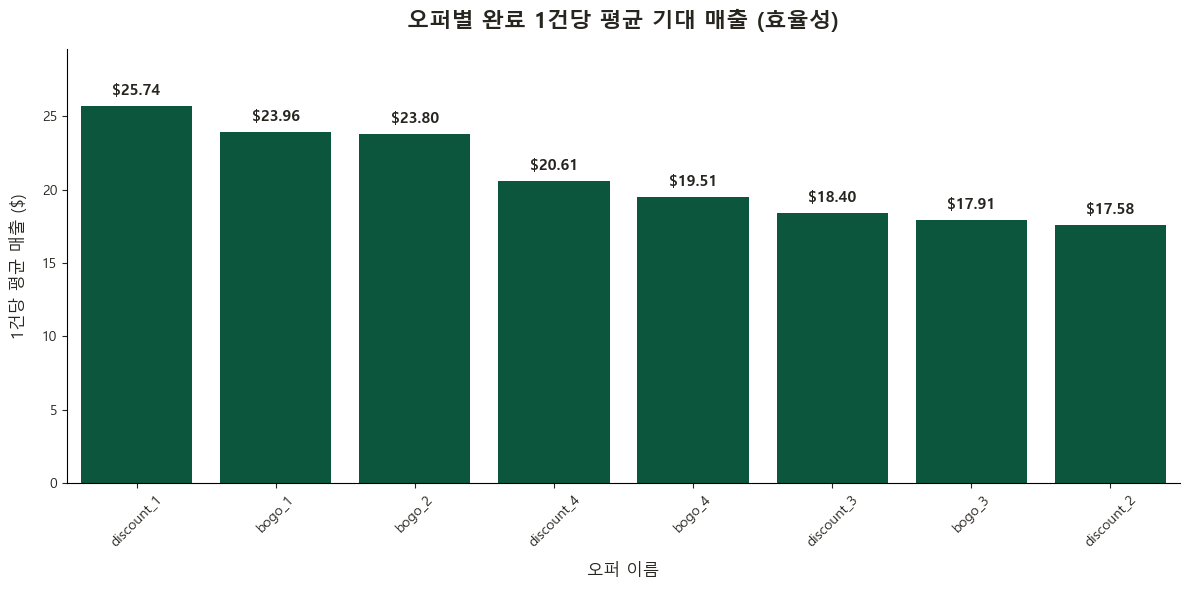


[오퍼별 완료 효율성 상세 데이터]


,offer_label,completed_count,total_revenue,revenue_per_completion($)
0,discount_1,"3,340 건","$85,985.53",$25.74
1,bogo_1,"3,635 건","$87,109.94",$23.96
2,bogo_2,"3,301 건","$78,562.14",$23.80
3,discount_4,"3,964 건","$81,687.95",$20.61
4,bogo_4,"4,262 건","$83,146.93",$19.51
5,discount_3,"5,265 건","$96,900.08",$18.40
6,bogo_3,"4,303 건","$77,066.31",$17.91
7,discount_2,"5,112 건","$89,848.17",$17.58


In [71]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=roi_df, 
    x='offer_label', 
    y='revenue_per_completion($)', 
    color=SB_GREEN 
)

# 숫자 붙이기
labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.ylim(0, roi_df['revenue_per_completion($)'].max() * 1.15)
plt.title('오퍼별 완료 1건당 평균 기대 매출 (효율성)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름', fontsize=12, labelpad=10)
plt.ylabel('1건당 평균 매출 ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n[오퍼별 완료 효율성 상세 데이터]")
display(roi_df.style.format({
    'completed_count': '{:,} 건', 
    'total_revenue': '${:,.2f}',
    'revenue_per_completion($)': '${:,.2f}'
}))

## 8. 오퍼별 ARPU 


ARPU = 총 매출액 / 고유 고객 수

In [74]:
arpu_df = sales_df.copy()
arpu_df['offer_label'] = arpu_df['offer_label'].fillna('일반 결제')

# 오퍼 레이블 별로 총 매출
revenue_sum = arpu_df.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')

# 오퍼별 고유 결제 고객 수
unique_users = arpu_df.groupby('offer_label')['person'].nunique().reset_index(name='user_count')

# 총 매출과 고객 수 머지
arpu_summary = pd.merge(revenue_sum, unique_users, on='offer_label')

# ARPU = 총 매출액 / 고유 고객 수
arpu_summary['ARPU($)'] = arpu_summary['total_revenue'] / arpu_summary['user_count']

# 순서
arpu_summary = arpu_summary.sort_values(by='ARPU($)', ascending=False).reset_index(drop=True)

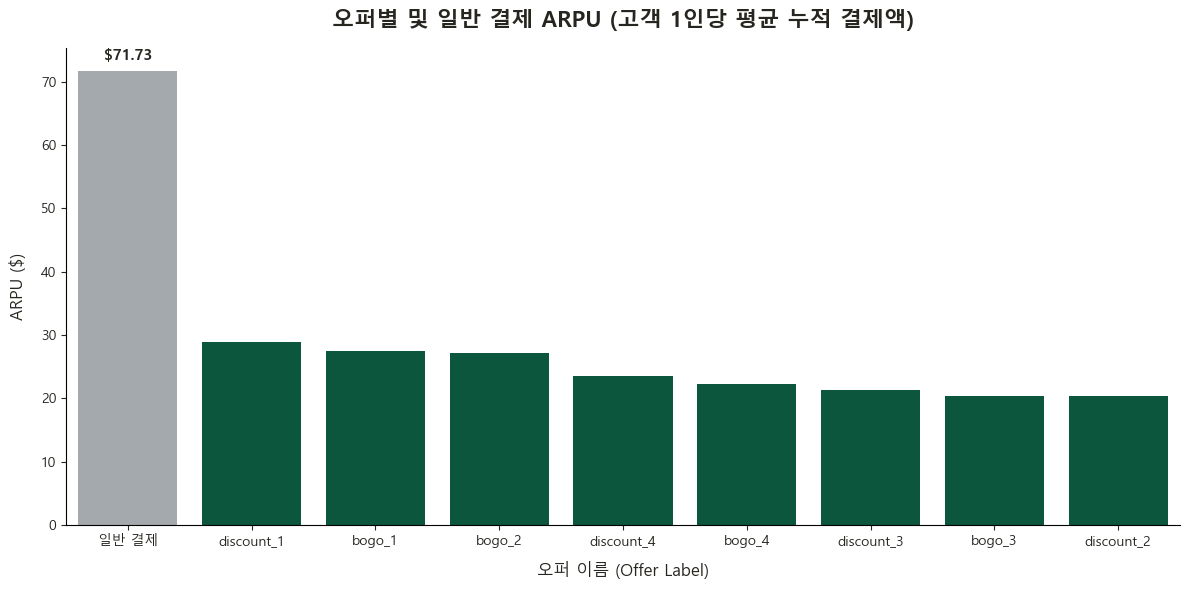


[오퍼별 및 일반 결제 ARPU]


,offer_label,total_revenue,user_count,ARPU($)
0,일반 결제,"$1,158,828.29","16,156 명",$71.73
1,discount_1,"$85,985.53","2,978 명",$28.87
2,bogo_1,"$87,109.94","3,177 명",$27.42
3,bogo_2,"$78,562.14","2,885 명",$27.23
4,discount_4,"$81,687.95","3,480 명",$23.47
5,bogo_4,"$83,146.93","3,741 명",$22.23
6,discount_3,"$96,900.08","4,530 명",$21.39
7,bogo_3,"$77,066.31","3,784 명",$20.37
8,discount_2,"$89,848.17","4,421 명",$20.32


In [75]:
plt.figure(figsize=(12, 6))
colors = ['#A2AAAD' if label == '일반 결제' else '#006241' for label in arpu_summary['offer_label']]

ax = sns.barplot(
    data=arpu_summary, 
    x='offer_label', 
    y='ARPU($)', 
    palette=colors
)

# 숫자
labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)


plt.title('오퍼별 및 일반 결제 ARPU (고객 1인당 평균 누적 결제액)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('ARPU ($)', fontsize=12, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

print("\n[오퍼별 및 일반 결제 ARPU]")
display(arpu_summary.style.format({
    'total_revenue': '${:,.2f}',
    'user_count': '{:,} 명',
    'ARPU($)': '${:,.2f}'
}))

# 비상 : 오퍼별 ARPU 

In [132]:
trans['txn_offer_type'].value_counts()

txn_offer_type
normal      108336
discount     15561
bogo         13666
multi         1390
Name: count, dtype: int64

multi의 기준이 bogo랑 discount 조합을 multi라고 함

bogo_1이랑 bogo_3 이렇게 같이 보내면 multi가 아닌 bogo 가 됨

In [133]:
import pandas as pd

# ['bogo_1', 'bogo_2'] 처럼 두 개 이상 적힌 데이터만 뽑음
multi_list_df = trans[trans['reward_offer_label_list'].str.contains(',', na=False)].copy()

# 확인
print(f"알맹이가 2개 이상인 데이터 총 건수: {len(multi_list_df):,}건")
display(multi_list_df[['person', 'amount', 'txn_offer_type', 'reward_offer_label_list']].head(10))

알맹이가 2개 이상인 데이터 총 건수: 2,505건


,person,amount,txn_offer_type,reward_offer_label_list
13,0011e0d4e6b944f998e987f904e8c1e5,22.05,multi,"['bogo_3', 'discount_1']"
17,0020c2b971eb4e9188eac86d93036a77,17.24,multi,"['bogo_2', 'discount_3']"
211,00ae03011f9f49b8a4b3e6d416678b0b,30.83,multi,"['bogo_1', 'discount_2']"
279,00c2f812f4604c8893152a5c6572030e,24.21,multi,"['bogo_2', 'discount_4']"
319,00cf1bbec83f4a658f8994e556db4633,33.28,discount,"['discount_3', 'discount_4']"
354,00d791e20c564add8056498e40eb56cc,10.38,bogo,"['bogo_2', 'bogo_3']"
361,00d7c95f793a4212af44e632fdc1e431,18.58,multi,"['bogo_3', 'discount_4']"
420,00ed7e22b32749cfafbfd88592d401d4,14.64,discount,"['discount_3', 'discount_4']"
453,0103de989e084e0fab400e80678d7591,20.20,discount,"['discount_1', 'discount_3']"
459,0103de989e084e0fab400e80678d7591,9.00,multi,"['bogo_4', 'discount_1']"


discount나 bogo에도 다중 오퍼

In [134]:
def create_exact_10_labels(row):
    txn_type = str(row['txn_offer_type']).strip().lower()
    
    if txn_type == 'normal':
        return '일반 결제'
    elif txn_type == 'multi':
        return '다중 오퍼'
    elif txn_type in ['bogo', 'discount']:
        label_list_str = str(row['reward_offer_label_list'])
        #뜯기
        clean_label = label_list_str.replace('[', '').replace(']', '').replace("'", "").replace('"', '').strip()
        
        # 청소 후 글자에 쉼표가 있다면 bogo_1, bogo_2 같은 것 -> 다중 오퍼
        if ',' in clean_label:
            return '다중 오퍼'
            
        # 제외
        if 'informational' in clean_label: 
            return None
            
        return clean_label 
    else:
        return None

trans_plot = trans.copy()
trans_plot['final_label'] = trans_plot.apply(create_exact_10_labels, axis=1)

trans_plot = trans_plot.dropna(subset=['final_label'])


In [135]:
arpu_summary = trans_plot.groupby('final_label').agg(
    total_revenue=('amount', 'sum'), # 총 매출
    user_count=('person', 'nunique') # 유저 카운트
).reset_index()

arpu_summary['ARPU($)'] = arpu_summary['total_revenue'] / arpu_summary['user_count']
arpu_summary = arpu_summary.sort_values(by='ARPU($)', ascending=False).reset_index(drop=True)
arpu_summary


,final_label,total_revenue,user_count,ARPU($)
0,일반 결제,1158828.29,16156,71.727426
1,discount_1,63811.75,2320,27.505065
2,bogo_1,72251.56,2690,26.859316
3,bogo_2,66567.32,2494,26.690986
4,다중 오퍼,61749.85,2410,25.622344
5,discount_4,65247.52,2935,22.230842
6,bogo_4,70338.90,3304,21.289013
7,discount_3,79538.92,3944,20.167069
8,bogo_3,62767.30,3230,19.432601
9,discount_2,74350.56,3915,18.991203


시각화

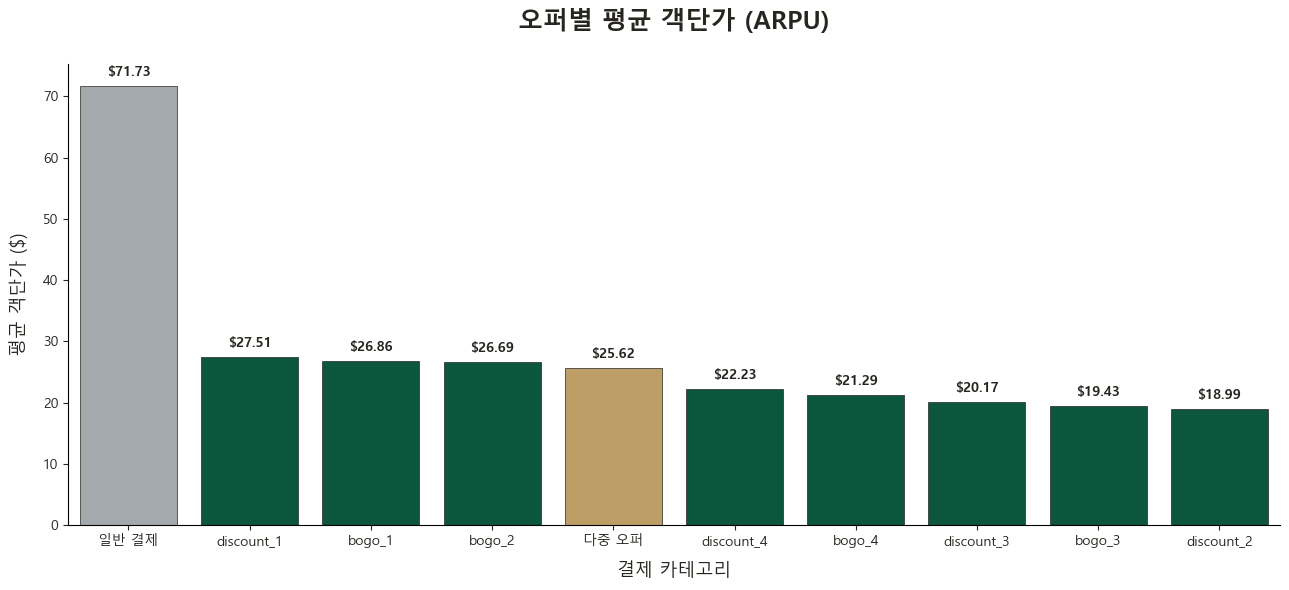

In [136]:
# 컬러 매핑
def get_sb_color(label):
    if label == '일반 결제':
        return SB_GREY
    elif label == '다중 오퍼':
        return SB_GOLD 
    else:
        return SB_GREEN 

plt.figure(figsize=(13, 6))

# 컬러 리스트
plot_colors = [get_sb_color(label) for label in arpu_summary['final_label']]

ax = sns.barplot(
    data=arpu_summary, 
    x='final_label', 
    y='ARPU($)', 
    palette=plot_colors,
    edgecolor=SB_BLACK,
    linewidth=0.5
)

for i, container in enumerate(ax.containers):
    labels = [f'${val:,.2f}' if pd.notnull(val) else '' for val in container.datavalues]
    ax.bar_label(
        container, 
        labels=labels, 
        padding=5, 
        fontweight='bold', 
        color=SB_BLACK, 
        fontsize=10
    )

plt.title('오퍼별 평균 객단가 (ARPU)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=13, labelpad=10)
plt.ylabel('평균 객단가 ($)', fontsize=13, labelpad=10)

plt.tight_layout()
plt.show()

# 퍼널2 사용해서 그래프 8개 그리기

received → completed 2단계만 거치는 오퍼

완료한 사람들 명단과 열람한 사람들 명단 뽑아서 머지

시간 검사해서 열람 시간, 완료 시간 제때 잘 봤나 보기

잘 열람한 시간들은 True, viewed를 안거치면 False

False만 뽑아서 funnel2_target으로 넣음

funnel2_target을 완료 이벤트와 inner 머지

In [76]:
# 1. 완료(completed)이벤트와 열람(viewed)이벤트
completed_df = merge_df[merge_df['event'] == 'completed'].copy()
viewed_df = merge_df[merge_df['event'] == 'viewed'][['person', 'offer_label', 'time']].copy()

# viewed_df의 time을 viewed_time(본 시간)으로 헷갈리니까 바꿈 
viewed_df.rename(columns={'time': 'viewed_time'}, inplace=True)

# 2. 완료 데이터에 열람 데이터 매핑 (person과 오퍼레이블기준)
merged_df = pd.merge(completed_df, viewed_df, on=['person', 'offer_label'], how='left')

# 3. 완료 시간이 받은 시간보다 더 큰지 확인
merged_df['is_valid_view'] = merged_df['viewed_time'] <= merged_df['time']
funnel_check = merged_df.groupby(['person', 'offer_label', 'time'])['is_valid_view'].any().reset_index()

# is_valid_view == False, 단 한 번도 제때 오퍼를 본 적이 없는 우연적 전환 명단
funnel2_target = funnel_check[funnel_check['is_valid_view'] == False]

funnel2_df = pd.merge(completed_df, 
    funnel2_target[['person', 'offer_label', 'time']], 
    on=['person', 'offer_label', 'time'], 
    how='inner')

print(f"최종 추출된 퍼널 2 건수: {len(funnel2_df):,} 건")

최종 추출된 퍼널 2 건수: 8,568 건


viewed 없는 것 확인

In [77]:
funnel2_df[funnel2_df['event']=='viewed'].size

0

In [78]:
funnel2_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8568 entries, 0 to 8567
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   person            8568 non-null   str    
 1   event             8568 non-null   str    
 2   time              8568 non-null   int64  
 3   offer_id          8568 non-null   str    
 4   amount            0 non-null      float64
 5   bonus_reward      8568 non-null   float64
 6   time_days         8568 non-null   int64  
 7   gender            8568 non-null   str    
 8   age               8427 non-null   float64
 9   customer_id       8568 non-null   str    
 10  became_member_on  8568 non-null   str    
 11  income            8427 non-null   float64
 12  income_missing    8568 non-null   int64  
 13  age_missing       8568 non-null   int64  
 14  reward            8568 non-null   float64
 15  difficulty        8568 non-null   float64
 16  duration          8568 non-null   float64
 17  web   

In [79]:
funnel2_df.head(2)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,0.0,NaN
1,0009655768c64bdeb2e877511632db8f,completed,414,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0,18,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,2,0,1.0,False


## 1. 총 발송 수

In [80]:
# 오퍼 수신 이벤트 (informational 제외)
received_df = merge_df[merge_df['event']=='received']

target_info = ['informational_1', 'informational_2']
received_df = received_df[~received_df['offer_label'].isin(target_info)]

# 총 몇 건의 오퍼
total_received_count = len(received_df)

# 오퍼를 받은 총 고객 수
unique_receivers = received_df['person'].nunique()

print(f"스타벅스가 뿌린 총 오퍼 건수: {total_received_count:,} 건")
print(f"오퍼를 받은 총 고객 수: {unique_receivers:,} 명")

스타벅스가 뿌린 총 오퍼 건수: 61,042 건
오퍼를 받은 총 고객 수: 16,928 명


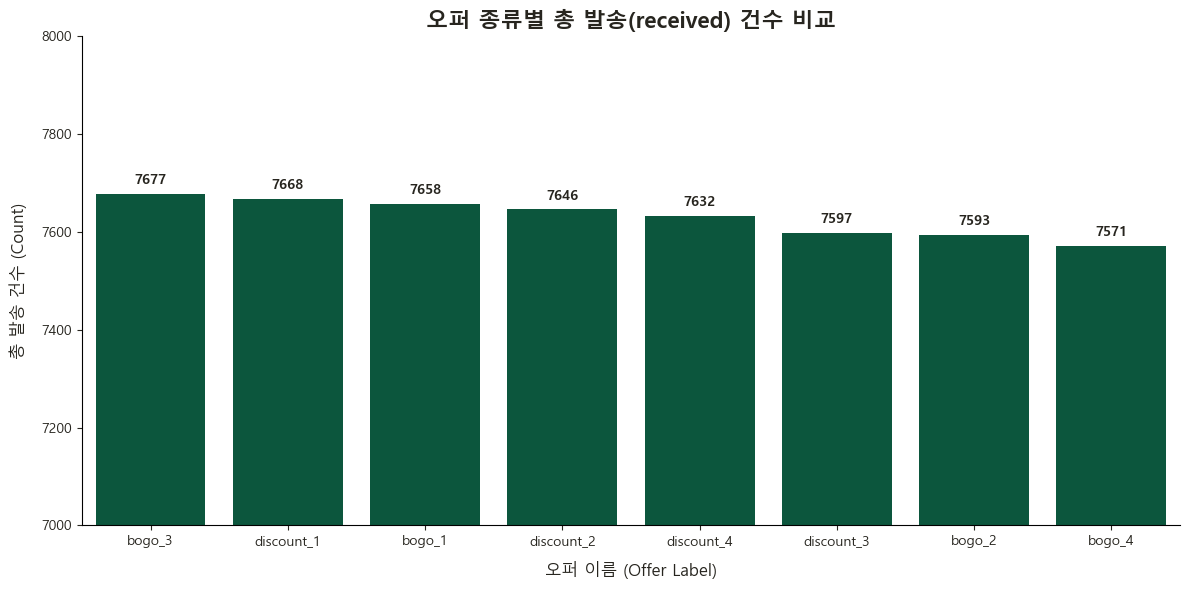

In [81]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=received_df, 
    x='offer_label', 
    order=received_df['offer_label'].value_counts().index
)
# y축 조절
plt.ylim(7000, 8000)

plt.title('오퍼 종류별 총 발송(received) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 발송 건수 (Count)', fontsize=12, labelpad=10)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. 총 열람 수

received -> completed로 이어진 건만 모았으므로 viewed는 없다.

그래서 총 열람 수는 나오지 않는다.

In [82]:
funnel2_df[funnel2_df['event']=='viewed']

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label


## 3. 총 완료 수

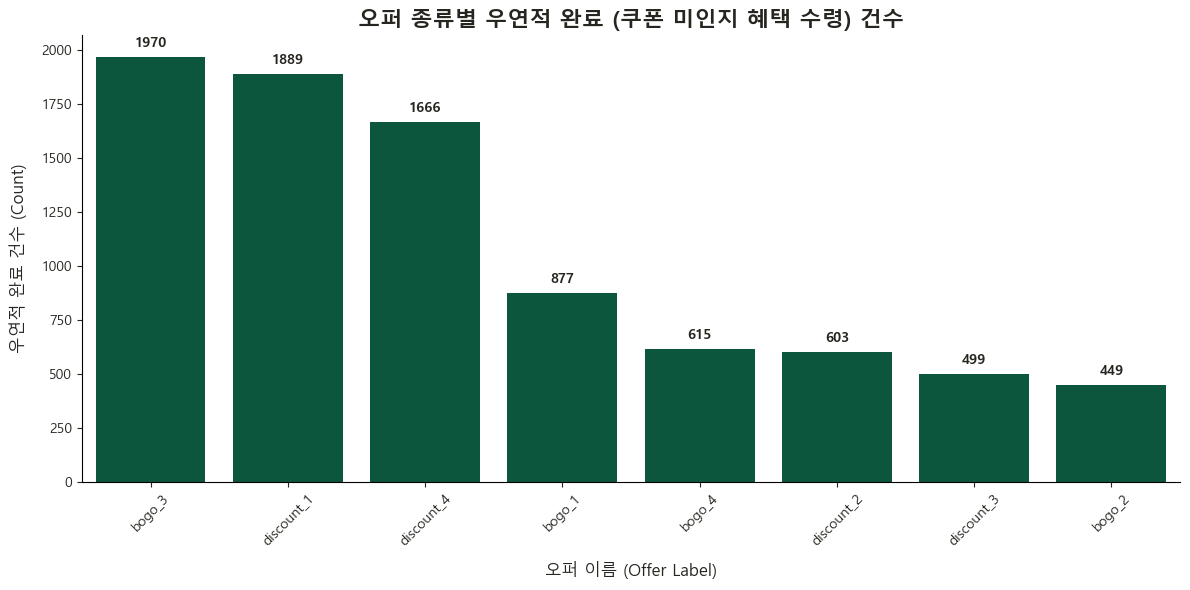

In [83]:
target_info = ['informational_1', 'informational_2']
funnel2_plot_df = funnel2_df[~funnel2_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=funnel2_plot_df, 
    x='offer_label', 
    order=funnel2_plot_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.title('오퍼 종류별 우연적 완료 (쿠폰 미인지 혜택 수령) 건수', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('우연적 완료 건수 (Count)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()